Dataset shape: (671205, 20)

Columns: ['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use', 'country_code', 'country', 'region', 'currency', 'partner_id', 'posted_time', 'disbursed_time', 'funded_time', 'term_in_months', 'lender_count', 'tags', 'borrower_genders', 'repayment_interval', 'date']

First few rows:
       id  funded_amount  loan_amount             activity          sector  \
0  653051          300.0        300.0  Fruits & Vegetables            Food   
1  653053          575.0        575.0             Rickshaw  Transportation   
2  653068          150.0        150.0       Transportation  Transportation   
3  653063          200.0        200.0           Embroidery            Arts   
4  653084          400.0        400.0           Milk Sales            Food   

                                                 use country_code   country  \
0            To buy seasonal, fresh fruits to sell.            PK  Pakistan   
1  to repair and maintain the auto rickshaw use

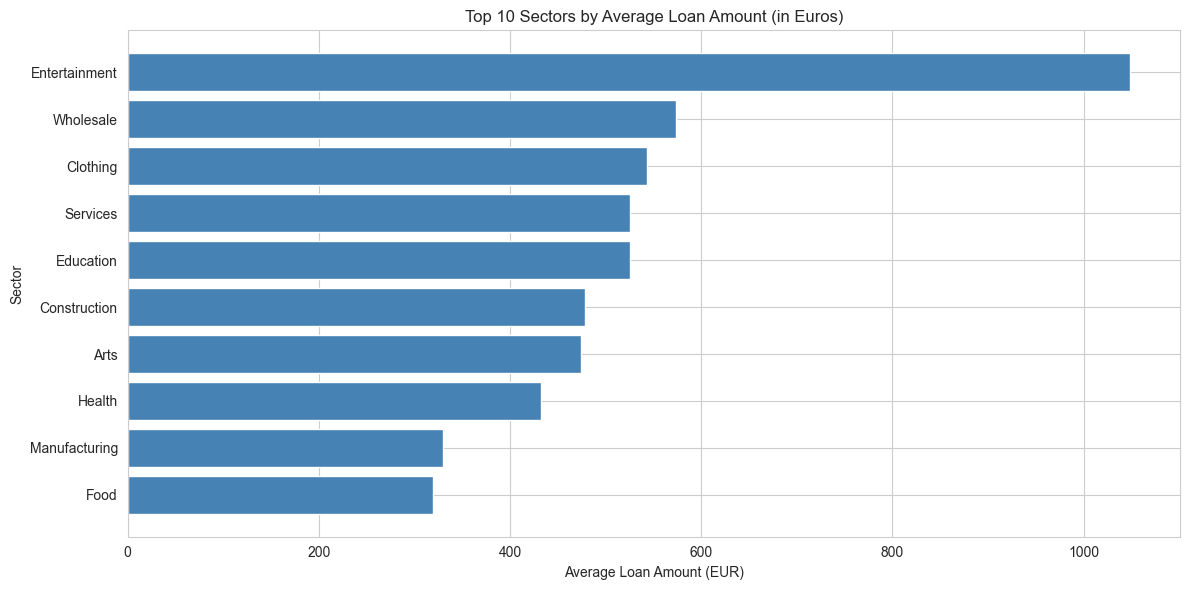


QUESTION 2: Loan Amount per Borrower by Activity

Top 15 activities by average loan per borrower (min 100 loans):
                 activity  avg_loan_per_borrower  num_loans  avg_num_borrowers
               Technology            4402.022016        178           1.005618
        Cleaning Services            3279.427307        145           1.048276
               Child Care            2348.352042        183           1.131148
Renewable Energy Products            1933.510370        585           1.203419
            Entertainment            1915.325900        443           1.137698
                   Health             933.028121       1235           2.182996
       Goods Distribution             902.466524        277           1.552347
                Utilities             879.060804        185           1.237838
                 Services             861.867830       9807           1.379525
                  Tourism             812.072180        187           1.529412
              El

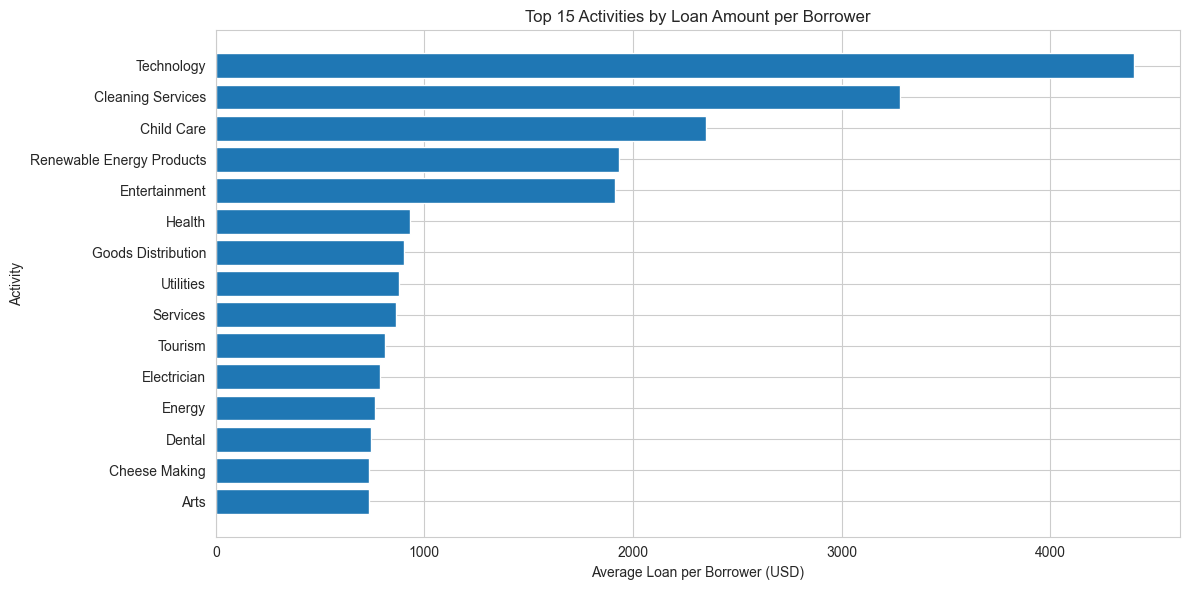


QUESTION 3: Loan Terms by Sector and Country

Sector-Country combinations with longest loan terms (min 50 loans):
     sector       country  avg_term_months  avg_loan_usd  num_loans
Agriculture        Belize        51.016000    912.200000        125
Agriculture         India        36.265515      9.765550       3416
Agriculture    Costa Rica        35.421842   1257.548180        934
Agriculture         Yemen        32.906250    473.125000        160
Agriculture United States        32.709677   7441.811414        403
Agriculture       Armenia        27.800000   1003.507963       4630
Agriculture     Palestine        26.918974   1654.100754        975
Agriculture       Moldova        26.752294    108.641123        218
Agriculture        Panama        24.876712   1488.013699         73
Agriculture       Albania        23.916551     12.831105        719
Agriculture        Kosovo        21.806818   1769.318182        440
Agriculture       Bolivia        21.577566   1758.790772       1257
A

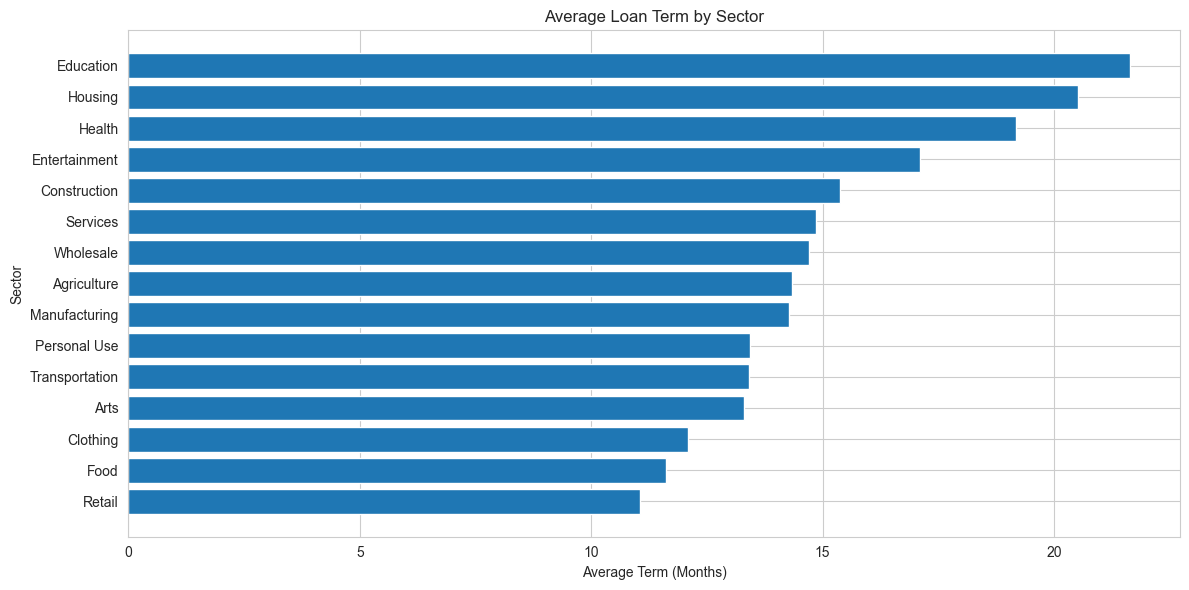


QUESTION 4: Gender Distribution and Loan Amounts by Sector

Average loan amount (USD) by sector and gender category:
gender_category  all_male   mixed  unknown
sector                                    
Agriculture        425.86  210.73   434.11
Arts              1232.24  474.67  1475.79
Clothing           663.64  636.57   614.15
Construction       614.71  481.31  1736.31
Education          692.67  572.09   636.91
Entertainment     1555.90  917.54  1842.68
Food               586.33  349.41   549.35
Health             400.07  559.33   706.80
Housing            500.61  240.97   492.36
Manufacturing      629.94  232.45   750.81
Personal Use       389.26  126.48   292.29
Retail             405.42  302.99   492.94
Services           885.15  532.92  1181.64
Transportation     438.52  143.90  1618.35
Wholesale          938.84  353.26  6251.97


Overall gender distribution:
gender_category
mixed       528461
all_male    138523
unknown       4221
Name: count, dtype: int64

Percentage distribut

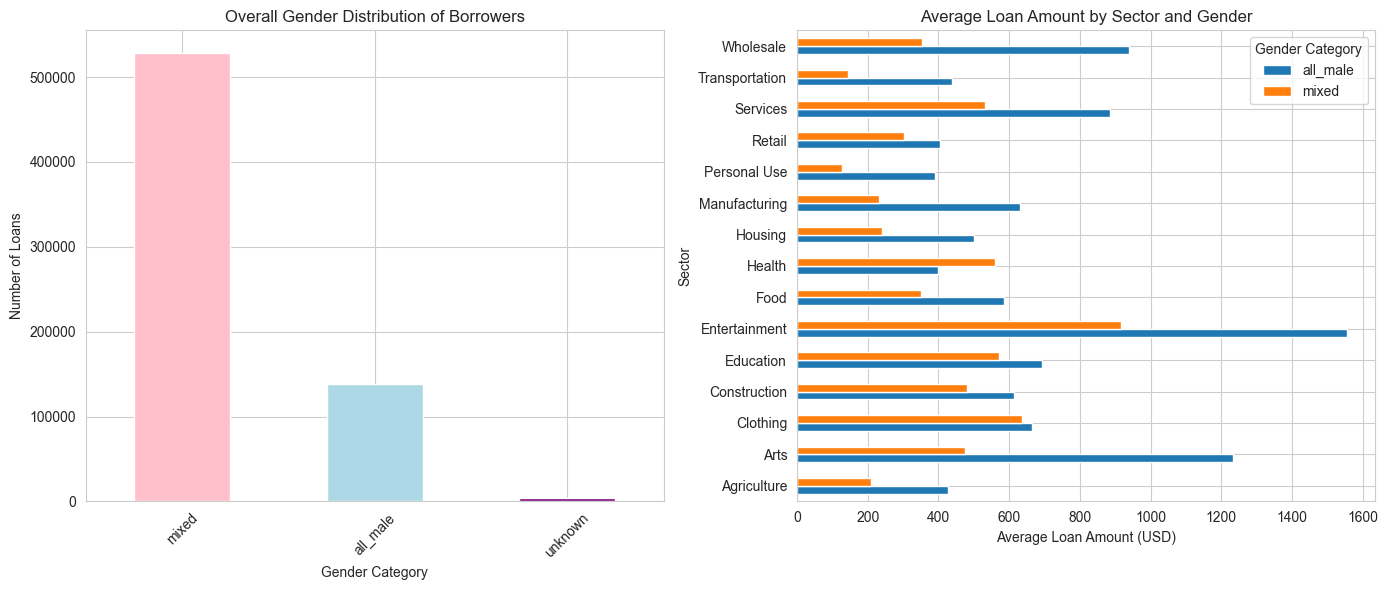


QUESTION 5: Top Countries by Average Number of Borrowers per Loan

Top 10 countries by average number of borrowers per loan:
                             country  avg_num_borrowers  num_loans
                             Burundi          20.029545        880
The Democratic Republic of the Congo          14.962577       3073
    Lao People's Democratic Republic          11.109017       1486
                            Paraguay          10.016130      11903
                             Senegal           9.958703       3269
                               Congo           9.804688        128
                              Malawi           9.407576       1320
                             Lesotho           8.829384        422
                              Rwanda           7.698886       6735
                                Mali           7.053472       6639


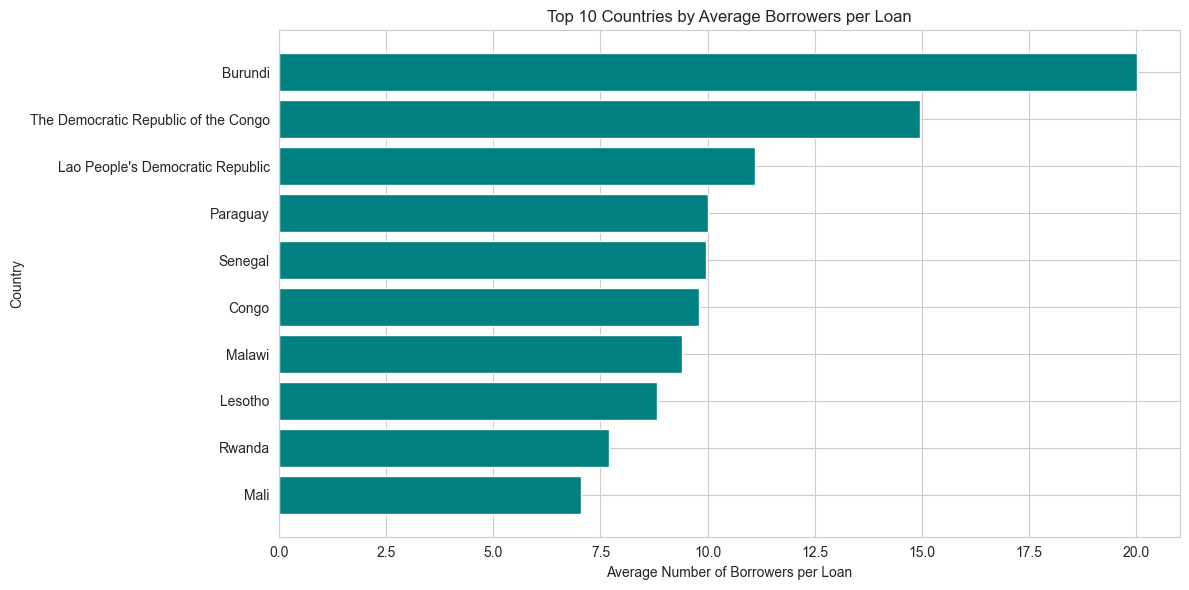


QUESTION 6: Loan Funding Rate by Sector

Sectors ranked by average funding rate:
        sector  avg_funding_rate  avg_loan_usd  num_loans
 Manufacturing          0.994983    387.671775       6208
          Arts          0.986543    557.788352      12060
     Wholesale          0.985849    675.225923        634
     Education          0.985611    618.452347      31013
  Personal Use          0.978424    189.704499      36385
  Construction          0.970399    563.104189       6268
          Food          0.967560    376.208240     136657
        Health          0.959777    508.874262       9223
   Agriculture          0.958031    271.967089     180302
        Retail          0.956063    316.055149     124494
      Clothing          0.951670    638.643019      32742
      Services          0.947273    618.748567      45140
Transportation          0.940367    281.533086      15518
       Housing          0.939861    306.772365      33731
 Entertainment          0.887208   1233.256360  

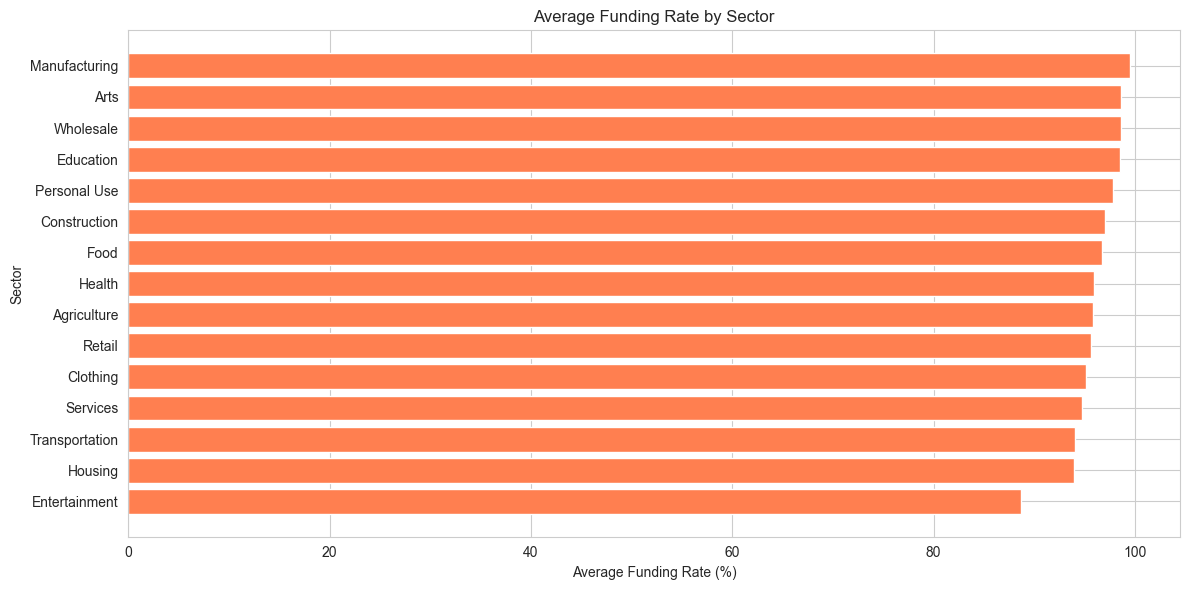

In [ ]:
#Author:Luis Vale 
#Date: November 2025 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')

# Load the dataset
df = pd.read_csv('kiva_loans.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

# Check for missing values
print("\n" + "="*80)
print("Missing values:")
print(df.isnull().sum())

# Info about the dataset
print("\n" + "="*80)
print("Dataset Info:")
print(df.info())

# QUESTION 1: What are the top 10 sectors with the highest average loan amounts?
# Operations used: groupby, aggregate, sort

print("\n" + "="*80)
print("QUESTION 1: What are the top 10 Sectors by Average Loan Amount considering EUR conversion")

# Currency conversion rates to EUR
currency_to_eur = {
    'USD': 0.85,  # US Dollar
    'PHP': 0.017,  # Philippine Peso
    'KES': 0.0082,  # Kenyan Shilling
    'PKR': 0.0081,  # Pakistani Rupee
    'VND': 0.000037,  # Vietnamese Dong
    'MXN': 0.045,  # Mexican Peso
    'UGX': 0.00023,  # Ugandan Shilling
    'PEN': 0.26,  # Peruvian Sol
    'IDR': 0.000064,  # Indonesian Rupiah
    'KHR': 0.00021,  # Cambodian Riel
    'GTQ': 0.12,  # Guatemalan Quetzal
    'HNL': 0.037,  # Honduran Lempira
    'NIO': 0.028,  # Nicaraguan Córdoba
    'COP': 0.00029,  # Colombian Peso
    'MDL': 0.048,  # Moldovan Leu
    'TJS': 0.094,  # Tajikistani Somoni
    'MAD': 0.094,  # Moroccan Dirham
    'GEL': 0.32,  # Georgian Lari
    'NAD': 0.065,  # Namibian Dollar
    'RWF': 0.0010,  # Rwandan Franc
    'EGP': 0.048,  # Egyptian Pound
    'XOF': 0.0015,  # West African CFA Franc
    'ALL': 0.0078,  # Albanian Lek
    'TZS': 0.00038,  # Tanzanian Shilling
    'SLR': 0.0055,  # Sri Lankan Rupee (assuming LKR)
    'INR': 0.014,  # Indian Rupee
    'JOD': 1.20,  # Jordanian Dinar
    'ILS': 0.24,  # Israeli Shekel
    'AMD': 0.0018,  # Armenian Dram
    'KGS': 0.013,  # Kyrgyzstani Som
    'ZMW': 0.085,  # Zambian Kwacha
    'SVC': 0.094,  # Salvadoran Colón
    'LAK': 0.00010,  # Lao Kip
    'BGN': 0.51,  # Bulgarian Lev
    'MZN': 0.014,  # Mozambican Metical
    'HTG': 0.013,  # Haitian Gourde
    'LRD': 0.0076,  # Liberian Dollar
    'MWK': 0.0012,  # Malawian Kwacha
    'CDF': 0.00052,  # Congolese Franc
    'BRL': 0.27,  # Brazilian Real
    'SLL': 0.000094,  # Sierra Leonean Leone
    'NPR': 0.0082,  # Nepalese Rupee
    'LBP': 0.00056,  # Lebanese Pound
    'AFN': 0.013,  # Afghan Afghani
    'PAB': 0.85,  # Panamanian Balboa
    'DOP': 0.018,  # Dominican Peso
    'MGA': 0.00026,  # Malagasy Ariary
    'WST': 0.33,  # Samoan Tālā
    'TOP': 0.37,  # Tongan Paʻanga
    'SBD': 0.11,  # Solomon Islands Dollar
    'EUR': 1.0,  # Euro
}

# Create a EUR conversion column
df['loan_amount_eur'] = df.apply(
    lambda row: row['loan_amount'] * currency_to_eur.get(row['currency'], 0.85),
    axis=1
)

# Also keep USD for other questions
currency_to_usd = {k: v/0.85 for k, v in currency_to_eur.items()}
df['loan_amount_usd'] = df.apply(
    lambda row: row['loan_amount'] * currency_to_usd.get(row['currency'], 1.0),
    axis=1
)

# Group by sector and calculate average loan amount in EUR
sector_avg = df.groupby('sector')['loan_amount_eur'].agg(['mean', 'count']).reset_index()
sector_avg.columns = ['sector', 'avg_loan_eur', 'num_loans']
sector_avg = sector_avg.sort_values('avg_loan_eur', ascending=False).head(10)

print("\nTop 10 sectors by average loan amount (EUR):")
print(sector_avg.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(sector_avg['sector'], sector_avg['avg_loan_eur'], color='steelblue')
plt.xlabel('Average Loan Amount (EUR)')
plt.ylabel('Sector')
plt.title('Top 10 Sectors by Average Loan Amount (in Euros)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# QUESTION 2: What is the loan amount per borrower ratio by activity?
# Operations used: apply, lambda, create new variable

print("\n" + "="*80)
print("QUESTION 2: Loan Amount per Borrower by Activity")
print("="*80)

# Create a new variable: loan amount per borrower
df['loan_per_borrower'] = df.apply(
    lambda row: row['loan_amount_usd'] / row['borrower_genders'].count(',') + 1 
    if pd.notna(row['borrower_genders']) and row['borrower_genders'].count(',') > 0
    else row['loan_amount_usd'],
    axis=1
)

# Alternative simpler calculation using actual number of borrowers
df['num_borrowers'] = df['borrower_genders'].apply(
    lambda x: len(x.split(',')) if pd.notna(x) else 1
)
df['loan_per_borrower'] = df['loan_amount_usd'] / df['num_borrowers']

# Group by activity and calculate statistics
activity_analysis = df.groupby('activity').agg({
    'loan_per_borrower': 'mean',
    'id': 'count',
    'num_borrowers': 'mean'
}).reset_index()
activity_analysis.columns = ['activity', 'avg_loan_per_borrower', 'num_loans', 'avg_num_borrowers']
activity_analysis = activity_analysis[activity_analysis['num_loans'] >= 100]  # Filter for activities with at least 100 loans
activity_analysis = activity_analysis.sort_values('avg_loan_per_borrower', ascending=False).head(15)

print("\nTop 15 activities by average loan per borrower (min 100 loans):")
print(activity_analysis.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(activity_analysis['activity'], activity_analysis['avg_loan_per_borrower'])
plt.xlabel('Average Loan per Borrower (USD)')
plt.ylabel('Activity')
plt.title('Top 15 Activities by Loan Amount per Borrower')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# QUESTION 3: How do loan terms vary by sector and country?
# Operations used: groupby with multiple columns, sort by multiple columns

print("\n" + "="*80)
print("QUESTION 3: Loan Terms by Sector and Country")
print("="*80)

# Group by sector and country
sector_country = df.groupby(['sector', 'country']).agg({
    'term_in_months': 'mean',
    'loan_amount_usd': 'mean',
    'id': 'count'
}).reset_index()
sector_country.columns = ['sector', 'country', 'avg_term_months', 'avg_loan_usd', 'num_loans']

# Filter for combinations with at least 50 loans
sector_country = sector_country[sector_country['num_loans'] >= 50]

# Sort by sector and then by average term
sector_country_sorted = sector_country.sort_values(['sector', 'avg_term_months'], ascending=[True, False])

print("\nSector-Country combinations with longest loan terms (min 50 loans):")
print(sector_country_sorted.head(20).to_string(index=False))

# Show shortest terms as well
print("\nSector-Country combinations with shortest loan terms (min 50 loans):")
print(sector_country_sorted.tail(20).to_string(index=False))

# Visualization: Average term by sector
sector_terms = df.groupby('sector')['term_in_months'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
plt.barh(sector_terms.index, sector_terms.values)
plt.xlabel('Average Term (Months)')
plt.ylabel('Sector')
plt.title('Average Loan Term by Sector')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# QUESTION 4: What is the gender distribution of borrowers, and how does it affect loan amounts across different sectors?
# Operations: apply/lambda for data transformation, groupby, aggregate


print("\n" + "="*80)
print("QUESTION 4: Gender Distribution and Loan Amounts by Sector")
print("="*80)

# --- Create a gender category variable ---
def categorize_gender(gender_str):
    if pd.isna(gender_str):
        return 'unknown'
    gender_str = gender_str.lower()
    female_count = gender_str.count('female')
    male_count = gender_str.count('male')
    total = female_count + male_count
    
    if total == 0:
        return 'unknown'
    elif female_count == total:
        return 'all_female'
    elif male_count == total:
        return 'all_male'
    else:
        return 'mixed'

df['gender_category'] = df['borrower_genders'].apply(categorize_gender)

# --- Analyze by sector and gender category ---
gender_sector = df.groupby(['sector', 'gender_category']).agg({
    'loan_amount_usd': 'mean',
    'id': 'count'
}).reset_index()

gender_sector.columns = ['sector', 'gender_category', 'avg_loan_usd', 'num_loans']

# --- Pivot for easier comparison ---
gender_pivot = gender_sector.pivot(index='sector', columns='gender_category', values='avg_loan_usd')
print("\nAverage loan amount (USD) by sector and gender category:")
print(gender_pivot.fillna(0).round(2))

# --- Overall gender distribution ---
print("\n\nOverall gender distribution:")
gender_dist = df['gender_category'].value_counts()
print(gender_dist)
print(f"\nPercentage distribution:")
print((gender_dist / len(df) * 100).round(2))

# --- Visualization ---
plt.figure(figsize=(14, 6))

# Left plot: overall gender distribution
plt.subplot(1, 2, 1)
gender_dist.plot(kind='bar', color=['pink', 'lightblue', 'purple', 'gray'])
plt.title('Overall Gender Distribution of Borrowers')
plt.xlabel('Gender Category')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)

# Right plot: average loan amount by sector and gender
plt.subplot(1, 2, 2)

# Handle missing categories safely
expected_cols = ['all_female', 'all_male', 'mixed']
valid_cols = [col for col in expected_cols if col in gender_pivot.columns]

# Optional warning if some gender types are missing
missing = set(expected_cols) - set(gender_pivot.columns)
if missing:
    print(f"\n⚠️ Warning: Missing gender categories in dataset: {', '.join(missing)}")

# Only plot existing categories
gender_pivot_plot = gender_pivot[valid_cols].fillna(0)

gender_pivot_plot.plot(kind='barh', ax=plt.gca())
plt.title('Average Loan Amount by Sector and Gender')
plt.xlabel('Average Loan Amount (USD)')
plt.ylabel('Sector')
plt.legend(title='Gender Category')

plt.tight_layout()
plt.show()


# QUESTION 5: Top Countries by Average Number of Borrowers per Loan
# Operations used: groupby, mean, sorting, visualization

print("\n" + "="*80)
print("QUESTION 5: Top Countries by Average Number of Borrowers per Loan")
print("="*80)

# Group by country to find average number of borrowers
borrowers_by_country = df.groupby('country').agg({
    'num_borrowers': 'mean',
    'id': 'count'
}).reset_index()
borrowers_by_country.columns = ['country', 'avg_num_borrowers', 'num_loans']

# Filter out small samples (fewer than 100 loans)
borrowers_by_country = borrowers_by_country[borrowers_by_country['num_loans'] >= 100]

# Sort by average number of borrowers
top_countries_borrowers = borrowers_by_country.sort_values('avg_num_borrowers', ascending=False).head(10)

print("\nTop 10 countries by average number of borrowers per loan:")
print(top_countries_borrowers.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(top_countries_borrowers['country'], top_countries_borrowers['avg_num_borrowers'], color='teal')
plt.xlabel('Average Number of Borrowers per Loan')
plt.ylabel('Country')
plt.title('Top 10 Countries by Average Borrowers per Loan')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# QUESTION 6: Loan Funding Rate by Sector
# Operations used : groupby, mean, sorting, visualization

print("\n" + "="*80)
print("QUESTION 6: Loan Funding Rate by Sector")
print("="*80)

# Ensure funding_rate column exists
if 'funding_rate' not in df.columns:
    df['funding_rate'] = df.apply(
        lambda row: (row['funded_amount'] / row['loan_amount'])
        if (pd.notna(row['funded_amount']) and row['loan_amount'] > 0)
        else 0,
        axis=1
    )

# Group by sector to analyze funding rate
sector_funding = df.groupby('sector').agg({
    'funding_rate': 'mean',
    'loan_amount_usd': 'mean',
    'id': 'count'
}).reset_index()
sector_funding.columns = ['sector', 'avg_funding_rate', 'avg_loan_usd', 'num_loans']

# Filter for sectors with at least 100 loans
sector_funding = sector_funding[sector_funding['num_loans'] >= 100]
sector_funding = sector_funding.sort_values('avg_funding_rate', ascending=False)

print("\nSectors ranked by average funding rate:")
print(sector_funding.head(15).to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(sector_funding['sector'], sector_funding['avg_funding_rate'] * 100, color='coral')
plt.xlabel('Average Funding Rate (%)')
plt.ylabel('Sector')
plt.title('Average Funding Rate by Sector')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()










